<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 1: Implementación de un modelo por Random Forest</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clasificadore basados en **Random Forest** para predecir la **aceptabilidad/seguridad de un automóvil**. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Entrenar dos modelos (con pocos y con muchos árboles) para observar cómo mejora la exactitud, demostrar el proceso de **selección de características** basado en la importancia de variables, y reconstruir el modelo con las variables más relevantes. </li>

</ul>
</div>

**Random Forest** (bosque aleatorio) es un algoritmo de **aprendizaje supervisado** basado en **ensamble** (*ensemble learning*). Tiene dos variantes: una para **clasificación** y otra para **regresión**. Es uno de los algoritmos más flexibles y fáciles de usar.

Construye **múltiples árboles de decisión** sobre distintas muestras de los datos, obtiene la predicción de cada árbol y selecciona la mejor solución mediante **votación**. Además, es un excelente indicador de la **importancia de las variables**.

> Al combinar muchos árboles se forma un "bosque"; de ahí el nombre **Random Forest**. Cuantos **más árboles**, mayor suele ser la exactitud (hasta estabilizarse).

#### Selección de características con Random Forest

El Random Forest permite **ordenar la importancia** de las variables. Durante el entrenamiento, se registra el **error out-of-bag (OOB)** y se promedia sobre el bosque.

Para medir la importancia de la característica *j*, se **permutan** sus valores en los datos y se recalcula el error OOB sobre ese conjunto perturbado. La **importancia** es la diferencia promedio de error OOB antes y después de la permutación, normalizada por su desviación estándar.

Las características que producen valores **grandes** de esta puntuación son más importantes. Con base en ella, conservaremos las más relevantes y descartaremos las menos útiles.

**Planteamiento del problema**

El objetivo es **predecir la aceptabilidad/seguridad de un automóvil** con un clasificador Random Forest en Python y scikit-learn, usando el [**Car Evaluation Data Set**](http://archive.ics.uci.edu/ml/datasets/Car+Evaluation) de la UCI.

El **Car Evaluation Data Set** relaciona la evaluación del automóvil (`class`) con **seis atributos de entrada**:

| Variable | Descripción | Valores |
|---|---|---|
| `buying` | Precio de compra | vhigh, high, med, low |
| `maint` | Costo de mantenimiento | vhigh, high, med, low |
| `doors` | Número de puertas | 2, 3, 4, 5more |
| `persons` | Capacidad de personas | 2, 4, more |
| `lug_boot` | Tamaño de la cajuela | small, med, big |
| `safety` | Seguridad estimada | low, med, high |
| `class` | **Objetivo:** evaluación | unacc, acc, good, vgood |

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Dataset real de la UCI (se descarga al vuelo)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
df = pd.read_csv(url, header=None)

# Alternativa local: df = pd.read_csv('C:/datasets/car.data', header=None)
df.shape

(1728, 7)

## 1.- Análisis exploratorio de datos

In [6]:
# Primeras filas (columnas aún sin nombre)
df.head()
#renomrbacion de columnas

col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.columns = col_names
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [8]:
df['persons'].value_counts()

persons
2       576
4       576
more    576
Name: count, dtype: int64

In [9]:
# Distribución de frecuencias
for col in col_names:
    print(df[col].value_counts())
    print(''*30)
    

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

persons
2       576
4       576
more    576
Name: count, dtype: int64

lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

safety
low     576
med     576
high    576
Name: count, dtype: int64

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64



### Variable objetivo `class` y valores faltantes
La variable objetivo es **ordinal** (unacc < acc < good < vgood).

In [10]:
df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [11]:
#observar si hay valores faltantes
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

## 2. Definir variables predictoras y objetivo

In [12]:
X=df.drop(['class'],axis=1)
y=df['class']
X


,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med
...,...,...,...,...,...,...
1723,low,low,5more,more,med,med
1724,low,low,5more,more,med,high
1725,low,low,5more,more,big,low
1726,low,low,5more,more,big,med


In [14]:
y

0       unacc
1       unacc
2       unacc
3       unacc
4       unacc
        ...  
1723     good
1724    vgood
1725    unacc
1726     good
1727    vgood
Name: class, Length: 1728, dtype: object

## 3. Dividir en entrenamiento y prueba

In [13]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((1382, 6), (346, 6))

## 4. Ingeniería de características (codificación)

Todas las variables son **categóricas ordinales**; las convertimos a números con `OrdinalEncoder` de scikit-learn (sin dependencias externas).

In [14]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
X_train = pd.DataFrame(encoder.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(encoder.transform(X_test), columns=X.columns, index=X_test.index)

X_train.head()

,buying,maint,doors,persons,lug_boot,safety
107,3.0,3.0,3.0,2.0,0.0,0.0
901,2.0,3.0,1.0,1.0,2.0,2.0
1709,1.0,1.0,3.0,0.0,0.0,0.0
706,0.0,2.0,2.0,0.0,1.0,2.0
678,0.0,2.0,1.0,0.0,1.0,1.0


In [15]:
X_train.shape, y_train.shape

((1382, 6), (1382,))

In [16]:
X_test.shape, y_test.shape

((346, 6), (346,))

In [17]:
from sklearn.preprocessing import OrdinalEncoder


In [18]:
encoder=OrdinalEncoder()

In [19]:
X_train_num=pd.DataFrame(encoder.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_train_num

,buying,maint,doors,persons,lug_boot,safety
107,3.0,3.0,3.0,2.0,0.0,0.0
901,2.0,3.0,1.0,1.0,2.0,2.0
1709,1.0,1.0,3.0,0.0,0.0,0.0
706,0.0,2.0,2.0,0.0,1.0,2.0
678,0.0,2.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...
1130,2.0,2.0,1.0,2.0,1.0,0.0
1294,2.0,1.0,3.0,2.0,0.0,2.0
860,0.0,1.0,3.0,2.0,1.0,0.0
1459,1.0,0.0,2.0,0.0,2.0,2.0


In [20]:
X_test_num=pd.DataFrame(encoder.fit_transform(X_test), columns=X.columns, index=X_test.index)
X_test_num

,buying,maint,doors,persons,lug_boot,safety
599,0.0,0.0,2.0,0.0,1.0,0.0
1201,2.0,1.0,0.0,1.0,1.0,2.0
628,0.0,0.0,3.0,0.0,0.0,2.0
1498,1.0,0.0,3.0,1.0,1.0,2.0
1263,2.0,1.0,2.0,2.0,1.0,1.0
...,...,...,...,...,...,...
100,3.0,3.0,3.0,2.0,2.0,2.0
274,3.0,2.0,2.0,0.0,1.0,2.0
1206,2.0,1.0,0.0,2.0,2.0,1.0
101,3.0,3.0,3.0,2.0,2.0,0.0


## 5. Random Forest con pocos árboles (modelo 1)

Entrena un bosque con **10 árboles** para tener una referencia.


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [22]:
tree=DecisionTreeClassifier(random_state=0).fit(X_train_num,y_train)
rfc=RandomForestClassifier(n_estimators=10,random_state=42)
rfc.fit(X_train_num, y_train)#agregar parametros como max_feactures, 

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred=rfc.predict(X_train_num)
y_pred

array(['unacc', 'unacc', 'unacc', ..., 'acc', 'unacc', 'acc'],
      shape=(1382,), dtype=object)

In [26]:
#usando max_feactures
from sklearn.ensemble import RandomForestClassifier

rf_10 = RandomForestClassifier(
    n_estimators=10,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_10.fit(X_train_num, y_train)


rf_10

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred_10 = rf_10.predict(X_test_num)

print("Primeras 20 predicciones:")
print(y_pred_10[:20])

Primeras 20 predicciones:
['unacc' 'acc' 'unacc' 'acc' 'unacc' 'acc' 'unacc' 'unacc' 'unacc' 'unacc'
 'vgood' 'good' 'unacc' 'unacc' 'unacc' 'unacc' 'unacc' 'unacc' 'unacc'
 'acc']


In [28]:
accuracy_10 = accuracy_score(y_test, y_pred_10)

print(f"Accuracy Random Forest - 10 árboles: {accuracy_10:.4f}")
print(f"Porcentaje: {accuracy_10 * 100:.2f}%")

Accuracy Random Forest - 10 árboles: 0.9451
Porcentaje: 94.51%


In [29]:
y_train_pred_10 = rf_10.predict(X_train_num)

accuracy_train_10 = accuracy_score(y_train, y_train_pred_10)
accuracy_test_10 = accuracy_score(y_test, y_pred_10)

print(f"Accuracy entrenamiento: {accuracy_train_10:.4f}")
print(f"Accuracy prueba:        {accuracy_test_10:.4f}")

Accuracy entrenamiento: 0.9986
Accuracy prueba:        0.9451


## 6. Random Forest con muchos arboles `n_estimators=100`

Entrena un modelo con **100 árboles** y comenta lo que puedas observar.

In [30]:
tree=DecisionTreeClassifier(random_state=0).fit(X_train_num,y_train)
rfc100=RandomForestClassifier(n_estimators=100,random_state=42)
rfc100.fit(X_train_num, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
rf_100 = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_100.fit(X_train_num, y_train)

rf_100

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred_100 = rf_100.predict(X_test_num)

print("Primeras 20 predicciones:")
print(y_pred_100[:20])

Primeras 20 predicciones:
['unacc' 'unacc' 'unacc' 'acc' 'unacc' 'acc' 'unacc' 'unacc' 'unacc'
 'unacc' 'vgood' 'good' 'unacc' 'unacc' 'unacc' 'unacc' 'unacc' 'unacc'
 'unacc' 'acc']


In [34]:
accuracy_100 = accuracy_score(y_test, y_pred_100)

print(f"Accuracy Random Forest - 100 árboles: {accuracy_100:.4f}")
print(f"Porcentaje: {accuracy_100 * 100:.2f}%")

Accuracy Random Forest - 100 árboles: 0.9740
Porcentaje: 97.40%


In [35]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Random Forest - 10 árboles",
        "Random Forest - 100 árboles"
    ],
    "Accuracy": [
        accuracy_10,
        accuracy_100
    ]
})

display(comparacion)

,Modelo,Accuracy
0,Random Forest - 10 árboles,0.945087
1,Random Forest - 100 árboles,0.973988


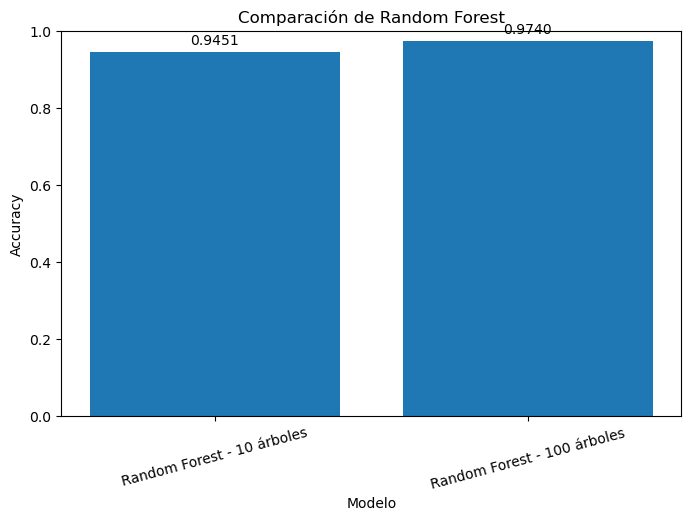

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparacion["Modelo"],
    comparacion["Accuracy"]
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.title("Comparación de Random Forest")

plt.xticks(rotation=15)

for i, valor in enumerate(comparacion["Accuracy"]):
    plt.text(
        i,
        valor + 0.02,
        f"{valor:.4f}",
        ha="center"
    )

plt.show()

## 7. Importancia de las características

Usa el atributo `feature_importances_` del bosque para ordenar las variables por relevancia.

In [38]:
df_importancia["Porcentaje"] = (
    df_importancia["Importancia"] * 100
)

display(
    df_importancia.style.format({
        "Importancia": "{:.4f}",
        "Porcentaje": "{:.2f}%"
    })
)

,Caracteristica,Importancia,Porcentaje
5,safety,0.2761,27.61%
3,persons,0.2184,21.84%
0,buying,0.1901,19.01%
1,maint,0.1622,16.22%
4,lug_boot,0.0856,8.56%
2,doors,0.0676,6.76%


In [42]:
caracteristica_menos_importante = (
    df_importancia
    .sort_values("Importancia")
    .iloc[0]["Caracteristica"]
)

print(
    "Característica menos importante:",
    caracteristica_menos_importante
)

Característica menos importante: doors


## 8. Visualizar la importancia de las características

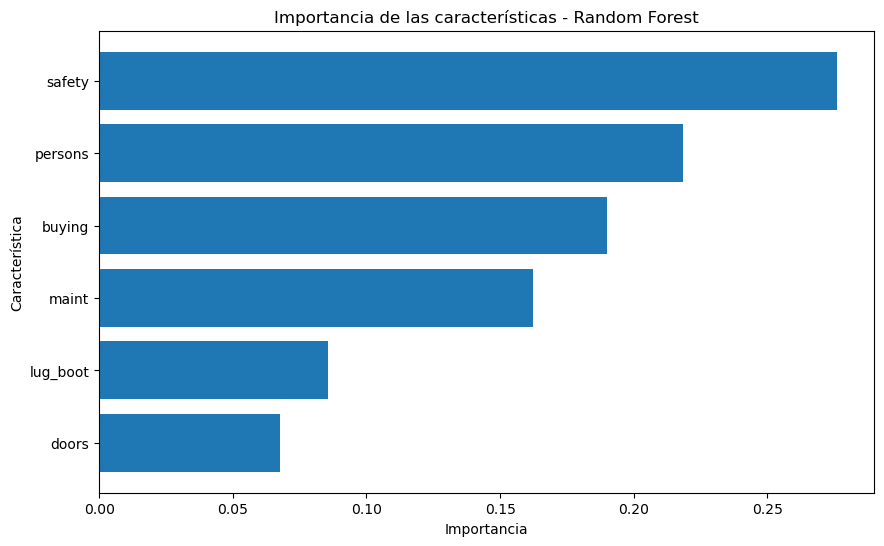

In [39]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_importancia["Caracteristica"],
    df_importancia["Importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.title("Importancia de las características - Random Forest")

plt.gca().invert_yaxis()

plt.show()

## 9. Reconstruir el modelo con las características seleccionadas

Elimina la variable **menos importante**, reconstruye el modelo y compara la exactitud.

In [43]:
# Nuevo conjunto de variables sin 'doors'
print(
    "Característica eliminada:",
    caracteristica_menos_importante
)

X_reducido = X.drop(
    columns=[caracteristica_menos_importante]
)

print("\nCaracterísticas originales:")
print(X.columns.tolist())

print("\nCaracterísticas después de la selección:")
print(X_reducido.columns.tolist())

Característica eliminada: doors

Características originales:
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

Características después de la selección:
['buying', 'maint', 'persons', 'lug_boot', 'safety']


In [44]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reducido,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train reducido:", X_train_red.shape)
print("X_test reducido:", X_test_red.shape)

X_train reducido: (1382, 5)
X_test reducido: (346, 5)


In [45]:
encoder_red = OrdinalEncoder()

X_train_red_num = pd.DataFrame(
    encoder_red.fit_transform(X_train_red),
    columns=X_train_red.columns,
    index=X_train_red.index
)

X_test_red_num = pd.DataFrame(
    encoder_red.transform(X_test_red),
    columns=X_test_red.columns,
    index=X_test_red.index
)

display(X_train_red_num.head())

,buying,maint,persons,lug_boot,safety
1120,2.0,2.0,1.0,1.0,2.0
1000,2.0,0.0,0.0,2.0,2.0
1504,1.0,0.0,2.0,2.0,2.0
1202,2.0,1.0,1.0,1.0,0.0
353,3.0,1.0,0.0,2.0,0.0


In [46]:
rf_reducido = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_reducido.fit(
    X_train_red_num,
    y_train_red
)

print(rf_reducido)

RandomForestClassifier(n_jobs=-1, random_state=42)


In [47]:
y_pred_reducido = rf_reducido.predict(X_test_red_num)

accuracy_reducido = accuracy_score(
    y_test_red,
    y_pred_reducido
)

print(
    f"Accuracy modelo reducido: "
    f"{accuracy_reducido:.4f}"
)

print(
    f"Porcentaje: "
    f"{accuracy_reducido * 100:.2f}%"
)

Accuracy modelo reducido: 0.9595
Porcentaje: 95.95%


In [48]:
comparacion_final = pd.DataFrame({
    "Modelo": [
        "Random Forest 10 árboles",
        "Random Forest 100 árboles",
        "Random Forest 100 árboles reducido"
    ],
    "Accuracy": [
        accuracy_10,
        accuracy_100,
        accuracy_reducido
    ]
})

comparacion_final["Accuracy (%)"] = (
    comparacion_final["Accuracy"] * 100
)

display(
    comparacion_final.style.format({
        "Accuracy": "{:.4f}",
        "Accuracy (%)": "{:.2f}%"
    })
)

,Modelo,Accuracy,Accuracy (%)
0,Random Forest 10 árboles,0.9451,94.51%
1,Random Forest 100 árboles,0.9740,97.40%
2,Random Forest 100 árboles reducido,0.9595,95.95%


## 10. Crea un Reporte de clasificación

Muestra **precision**, **recall**, **f1-score** y **support** por clase.

In [52]:
from sklearn.metrics import classification_report
print("REPORTE DE CLASIFICACIÓN")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_100,
        digits=4
    ))

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

         acc     0.9868    0.9036    0.9434        83
        good     0.6471    1.0000    0.7857        11
       unacc     0.9916    1.0000    0.9958       235
       vgood     1.0000    0.9412    0.9697        17

    accuracy                         0.9740       346
   macro avg     0.9064    0.9612    0.9236       346
weighted avg     0.9799    0.9740    0.9752       346



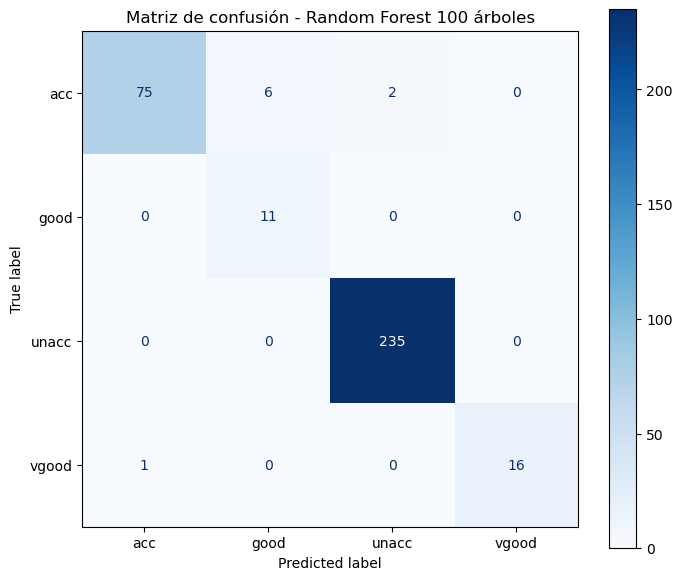

In [54]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(
    y_test,
    y_pred_100
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_100.classes_
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title("Matriz de confusión - Random Forest 100 árboles")
plt.show()

In [55]:
print("REPORTE DE CLASIFICACIÓN - MODELO REDUCIDO")
print("=" * 70)

print(
    classification_report(
        y_test_red,
        y_pred_reducido,
        digits=4
    )
)

REPORTE DE CLASIFICACIÓN - MODELO REDUCIDO
              precision    recall  f1-score   support

         acc     0.9221    0.9221    0.9221        77
        good     0.8667    0.9286    0.8966        14
       unacc     0.9794    0.9835    0.9814       242
       vgood     0.9091    0.7692    0.8333        13

    accuracy                         0.9595       346
   macro avg     0.9193    0.9008    0.9084       346
weighted avg     0.9595    0.9595    0.9592       346



In [56]:
reporte_100 = classification_report(
    y_test,
    y_pred_100,
    output_dict=True
)

reporte_reducido = classification_report(
    y_test_red,
    y_pred_reducido,
    output_dict=True
)

comparacion_metricas = pd.DataFrame({
    "Modelo": [
        "Random Forest 100 árboles",
        "Random Forest reducido"
    ],
    "Precision weighted": [
        reporte_100["weighted avg"]["precision"],
        reporte_reducido["weighted avg"]["precision"]
    ],
    "Recall weighted": [
        reporte_100["weighted avg"]["recall"],
        reporte_reducido["weighted avg"]["recall"]
    ],
    "F1 weighted": [
        reporte_100["weighted avg"]["f1-score"],
        reporte_reducido["weighted avg"]["f1-score"]
    ],
    "Accuracy": [
        accuracy_100,
        accuracy_reducido
    ]
})

display(
    comparacion_metricas.style.format({
        "Precision weighted": "{:.4f}",
        "Recall weighted": "{:.4f}",
        "F1 weighted": "{:.4f}",
        "Accuracy": "{:.4f}"
    })
)

,Modelo,Precision weighted,Recall weighted,F1 weighted,Accuracy
0,Random Forest 100 árboles,0.9799,0.9740,0.9752,0.9740
1,Random Forest reducido,0.9595,0.9595,0.9592,0.9595
